# **Анализ полученных результатов. Проверка гипотез.**

## Подготовка данных

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("all_exp_results.csv")
df

,dataset,model,method,modules,rank,time,gpu,loss,f1,accuracy,pst_dataset
0,EN,qwen2.5,baseline,NaN,NaN,22.516667,11.909000,169.500000,0.620000,0.620000,30000
1,EN,qwen2.5,LoRA,q+v,4.0,57.816667,8.530000,0.819336,0.935873,0.935789,30000
2,EN,qwen2.5,LoRA,q+v,8.0,57.816667,8.540000,0.436279,0.937984,0.938026,30000
3,EN,qwen2.5,LoRA,q+v,16.0,57.577032,8.540000,0.290283,0.945238,0.945263,30000
4,EN,qwen2.5,LoRA,q+v,32.0,60.923333,8.550000,0.287354,0.947105,0.947105,30000
...,...,...,...,...,...,...,...,...,...,...,...
513,RU,qwen3,QLoRA fp4,q+k+v,32.0,2.645973,4.757506,0.551760,0.804386,0.803945,300
514,RU,qwen3,QLoRA fp4,q+k+v+o,4.0,2.781251,4.841617,1.075496,0.527577,0.537263,300
515,RU,qwen3,QLoRA fp4,q+k+v+o,8.0,2.732979,4.863017,0.858874,0.655355,0.660862,300
516,RU,qwen3,QLoRA fp4,q+k+v+o,16.0,2.719546,4.889461,0.563589,0.798812,0.798831,300


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   dataset      518 non-null    object 
 1   model        518 non-null    object 
 2   method       518 non-null    object 
 3   modules      504 non-null    object 
 4   rank         504 non-null    float64
 5   time         518 non-null    float64
 6   gpu          518 non-null    float64
 7   loss         518 non-null    float64
 8   f1           518 non-null    float64
 9   accuracy     518 non-null    float64
 10  pst_dataset  518 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 44.6+ KB


In [4]:
import pandas as pd
import numpy as np
from scipy import stats

df_clean = df.copy()

# Убираем baseline
df_clean = df_clean[df_clean['method'] != 'baseline']

# Убираем NaN
df_clean = df_clean.dropna(subset=['accuracy', 'loss', 'model', 'pst_dataset'])

## Функции для расчетов

In [5]:
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(
        ((nx - 1)*np.std(x, ddof=1)**2 + (ny - 1)*np.std(y, ddof=1)**2) / dof
    )

def run_test(group1, group2, metric_name):
    # Проверка нормальности
    p1 = stats.shapiro(group1)[1] if len(group1) < 5000 else 1
    p2 = stats.shapiro(group2)[1] if len(group2) < 5000 else 1

    normal = (p1 > 0.05) and (p2 > 0.05)

    if normal:
        stat, p = stats.ttest_ind(group1, group2, equal_var=False)
        test_name = "t-test"
    else:
        stat, p = stats.mannwhitneyu(group1, group2, alternative='two-sided')
        test_name = "Mann-Whitney"

    d = cohens_d(group1, group2)

    print(f"\n=== {metric_name} ===")
    print(f"Test: {test_name}")
    print(f"p-value: {p:.6f}")
    print(f"Effect size (Cohen's d): {d:.3f}")
    print(f"Mean Qwen2.5: {np.mean(group1):.4f}")
    print(f"Mean Qwen3:  {np.mean(group2):.4f}")

    if p < 0.05:
        print("Статистически значимо")
    else:
        print("НЕ значимо")

In [6]:
# Берём только эксперименты с rank
rank_df = df.copy()
rank_df = rank_df.dropna(subset=['rank', 'accuracy'])

# Убираем baseline
rank_df = rank_df[rank_df['method'] != 'baseline']

# Приводим rank к int
rank_df['rank'] = rank_df['rank'].astype(int)

## **Гипотезы**

###**H1**: Qwen2.5-1.5B показывает сопоставимое или лучшее качество при достаточном объёме данных (более 15 000 образцов в каждом классе обучающей выборки).

In [7]:
# H1
large_data = df_clean[df_clean['pst_dataset'] >= 15000]

qwen25 = large_data[large_data['model'] == 'qwen2.5']['accuracy']
qwen3 = large_data[large_data['model'] == 'qwen3']['accuracy']

print("H1: Qwen2.5 vs Qwen3 на больших данных")
run_test(qwen25, qwen3, "Accuracy")

H1: Qwen2.5 vs Qwen3 на больших данных

=== Accuracy ===
Test: Mann-Whitney
p-value: 0.000001
Effect size (Cohen's d): 0.763
Mean Qwen2.5: 0.9406
Mean Qwen3:  0.9361
Статистически значимо


Получено p = 0.000001, что свидетельствует о наличии статистически значимых различий

## **H2:** Qwen3-0.6B превосходит Qwen2.5-1.5B при 300-3000 образцов в каждом классе обучающей выборки.

In [8]:
# H2
small_data = df_clean[df_clean['pst_dataset'] <= 3000]

qwen25 = small_data[small_data['model'] == 'qwen2.5']['accuracy']
qwen3 = small_data[small_data['model'] == 'qwen3']['accuracy']

print("\nH2: Преимущество Qwen3 на малых данных")
run_test(qwen25, qwen3, "Accuracy")


H2: Преимущество Qwen3 на малых данных

=== Accuracy ===
Test: Mann-Whitney
p-value: 0.026086
Effect size (Cohen's d): -0.141
Mean Qwen2.5: 0.8103
Mean Qwen3:  0.8297
Статистически значимо


Получено p = 0.026086, что свидетельствует о наличии статистически значимых различий

## **H3:** Qwen3-0.6B даёт более стабильные результаты (меньше разброс loss)

In [9]:
qwen25_loss = df_clean[df_clean['model'] == 'qwen2.5']['loss']
qwen3_loss = df_clean[df_clean['model'] == 'qwen3']['loss']

# Levene test — на равенство дисперсий
stat, p = stats.levene(qwen25_loss, qwen3_loss)

print("\nH3: Стабильность (разброс loss)")
print(f"Levene test p-value: {p:.6f}")

std_25 = np.std(qwen25_loss)
std_3 = np.std(qwen3_loss)

print(f"Std Qwen2.5: {std_25:.4f}")
print(f"Std Qwen3:  {std_3:.4f}")

if p < 0.05:
    print("Разброс статистически различается")
else:
    print("Разница в разбросе НЕ значима")

if std_3 < std_25:
    print("Qwen3 более стабильна (меньше разброс)")
else:
    print("Qwen2.5 более стабильна")


H3: Стабильность (разброс loss)
Levene test p-value: 0.000069
Std Qwen2.5: 4.8281
Std Qwen3:  0.2196
Разброс статистически различается
Qwen3 более стабильна (меньше разброс)


Для сравнения стабильности использован тест Левена. Разброс loss у модели Qwen3 статистически меньше.

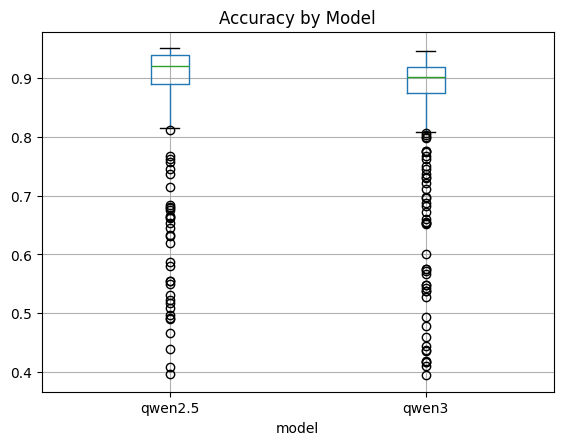

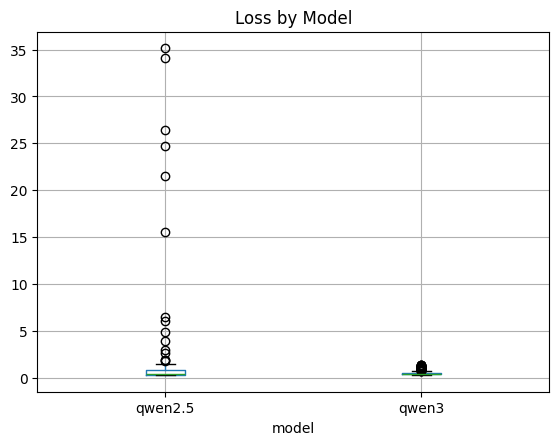

In [10]:
import matplotlib.pyplot as plt

# Accuracy boxplot
df_clean.boxplot(column='accuracy', by='model')
plt.title("Accuracy by Model")
plt.suptitle("")
plt.show()

# Loss boxplot
df_clean.boxplot(column='loss', by='model')
plt.title("Loss by Model")
plt.suptitle("")
plt.show()

## **H7:** Начиная с rank = 8, прирост качества становится минимальным. Увеличение до 32 даёт менее 0.5–1% прироста к accuracy.
## **H8:** Увеличение rank даёт убывающую отдачу после rank=16


**Qwen 2.5-1.5**

In [11]:
rank_df_2 = rank_df[rank_df['model'] == 'qwen2.5']

In [12]:
r4 = rank_df_2[rank_df_2['rank'] == 4]['accuracy']
r8 = rank_df_2[rank_df_2['rank'] == 8]['accuracy']
r16 = rank_df_2[rank_df_2['rank'] == 16]['accuracy']
r32 = rank_df_2[rank_df_2['rank'] == 32]['accuracy']

stat, p = stats.kruskal(r4, r8, r16, r32)

print("H7-H8: Влияние rank")
print(f"Kruskal-Wallis p-value: {p:.6f}")

if p < 0.05:
    print("Есть различия между rank")
else:
    print("Различий нет (плато)")

H7-H8: Влияние rank
Kruskal-Wallis p-value: 0.126537
Различий нет (плато)


In [13]:
from itertools import combinations

ranks = [4, 8, 16, 32]

print("\nПопарные сравнения:")

for r1, r2 in combinations(ranks, 2):
    g1 = rank_df_2[rank_df_2['rank'] == r1]['accuracy']
    g2 = rank_df_2[rank_df_2['rank'] == r2]['accuracy']

    stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')

    print(f"rank {r1} vs {r2}: p={p:.6f}, mean_diff={np.mean(g2)-np.mean(g1):.4f}")


Попарные сравнения:
rank 4 vs 8: p=0.353394, mean_diff=0.0137
rank 4 vs 16: p=0.095626, mean_diff=0.0312
rank 4 vs 32: p=0.036250, mean_diff=0.0499
rank 8 vs 16: p=0.347138, mean_diff=0.0175
rank 8 vs 32: p=0.163908, mean_diff=0.0361
rank 16 vs 32: p=0.472621, mean_diff=0.0187


Увеличение rank после 16 не даёт значимого прироста

**Qwen3-0.6**

In [14]:
rank_df_3 = rank_df[rank_df['model'] == 'qwen3']

In [15]:
r4 = rank_df_3[rank_df_3['rank'] == 4]['accuracy']
r8 = rank_df_3[rank_df_3['rank'] == 8]['accuracy']
r16 = rank_df_3[rank_df_3['rank'] == 16]['accuracy']
r32 = rank_df_3[rank_df_3['rank'] == 32]['accuracy']

stat, p = stats.kruskal(r4, r8, r16, r32)

print("H7-H8: Влияние rank")
print(f"Kruskal-Wallis p-value: {p:.6f}")

if p < 0.05:
    print("Есть различия между rank")
else:
    print("Различий нет (плато)")

H7-H8: Влияние rank
Kruskal-Wallis p-value: 0.016126
Есть различия между rank


In [16]:
from itertools import combinations

ranks = [4, 8, 16, 32]

print("\nПопарные сравнения:")

for r1, r2 in combinations(ranks, 2):
    g1 = rank_df_3[rank_df_3['rank'] == r1]['accuracy']
    g2 = rank_df_3[rank_df_3['rank'] == r2]['accuracy']

    stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')

    print(f"rank {r1} vs {r2}: p={p:.6f}, mean_diff={np.mean(g2)-np.mean(g1):.4f}")


Попарные сравнения:
rank 4 vs 8: p=0.281500, mean_diff=0.0283
rank 4 vs 16: p=0.050236, mean_diff=0.0534
rank 4 vs 32: p=0.004183, mean_diff=0.0729
rank 8 vs 16: p=0.264647, mean_diff=0.0251
rank 8 vs 32: p=0.030469, mean_diff=0.0446
rank 16 vs 32: p=0.224633, mean_diff=0.0195


Качество продолжает расти при увеличении rank

**Вывод:**

Для модели Qwen2.5 наблюдается эффект насыщения качества при rank ≥ 16.
В то же время для Qwen3 статистически значимого плато не выявлено, что указывает на более эффективное использование высоких значений rank.

## **H9:** Высокий rank (16-32) неэффективен при малом объёме данных (менее 3000 образцов в каждом классе обучающей выборки)

In [17]:
small = rank_df[rank_df['pst_dataset'] <= 3000]

low_rank = small[small['rank'].isin([4, 8])]['accuracy']
high_rank = small[small['rank'].isin([16, 32])]['accuracy']

stat, p = stats.mannwhitneyu(low_rank, high_rank, alternative='two-sided')

print("\nH9: Rank на малых данных")
print(f"p-value: {p:.6f}")
print(f"Low rank mean: {np.mean(low_rank):.4f}")
print(f"High rank mean: {np.mean(high_rank):.4f}")

if p < 0.05:
    print("Различие значимо")
else:
    print("Различие незначимо")

if np.mean(high_rank) <= np.mean(low_rank):
    print("Высокий rank неэффективен (подтверждение H9)")


H9: Rank на малых данных
p-value: 0.000076
Low rank mean: 0.7908
High rank mean: 0.8557
Различие значимо


**Вывод**

Гипотеза не подтверждается (различия значимы)

## **H10:** Оптимальный rank зависит от объёма данных: 	малые данные - rank=4-8, большие - rank=16


In [18]:
def analyze_by_size(df, label):
    low = df[df['rank'].isin([4, 8])]['accuracy']
    high = df[df['rank'].isin([16, 32])]['accuracy']

    stat, p = stats.mannwhitneyu(low, high)

    print(f"\n{label}")
    print(f"p-value: {p:.6f}")
    print(f"Low rank mean: {np.mean(low):.4f}")
    print(f"High rank mean: {np.mean(high):.4f}")

# Малые данные
small = rank_df[rank_df['pst_dataset'] <= 3000]
analyze_by_size(small, "Small data")

# Большие данные
large = rank_df[rank_df['pst_dataset'] >= 15000]
analyze_by_size(large, "Large data")


Small data
p-value: 0.000076
Low rank mean: 0.7908
High rank mean: 0.8557

Large data
p-value: 0.000006
Low rank mean: 0.9360
High rank mean: 0.9407


**Вывод:** Гипотеза не подтверждается (различия значимы)

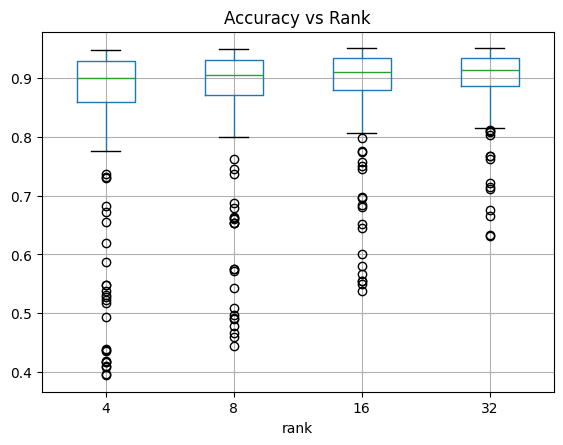

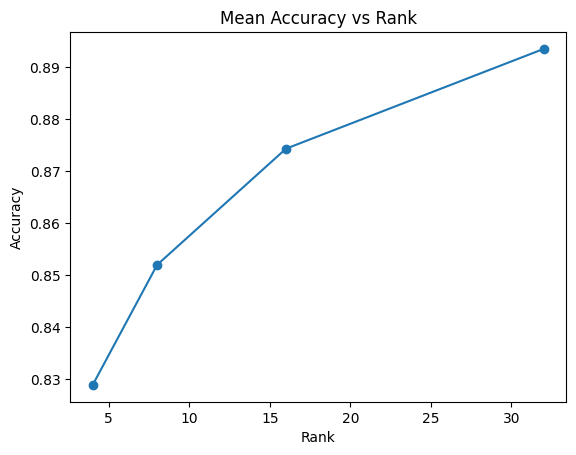

In [19]:
import matplotlib.pyplot as plt

# Boxplot
rank_df.boxplot(column='accuracy', by='rank')
plt.title("Accuracy vs Rank")
plt.suptitle("")
plt.show()

mean_acc = rank_df.groupby('rank')['accuracy'].mean()

plt.plot(mean_acc.index, mean_acc.values, marker='o')
plt.xlabel("Rank")
plt.ylabel("Accuracy")
plt.title("Mean Accuracy vs Rank")
plt.show()

**ANOVA**

In [20]:
import pandas as pd

anova_df = df.copy()

# Убираем baseline
anova_df = anova_df[anova_df['method'] != 'baseline']

# Убираем NaN
anova_df = anova_df.dropna(subset=['rank', 'accuracy', 'pst_dataset'])

# Категории
anova_df['rank'] = anova_df['rank'].astype(int).astype(str)
anova_df['pst_dataset'] = anova_df['pst_dataset'].astype(str)

# отдельно по моделям:
# anova_df = anova_df[anova_df['model'] == 'qwen3']

In [21]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('accuracy ~ C(rank) * C(pst_dataset)', data=anova_df).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                          sum_sq     df           F         PR(>F)
C(rank)                 0.295749    3.0   35.802985   6.767406e-21
C(pst_dataset)          5.238798    5.0  380.520644  2.040205e-164
C(rank):C(pst_dataset)  0.692457   15.0   16.765566   2.190147e-35
Residual                1.321675  480.0         NaN            NaN


In [22]:
for m in ['qwen2.5', 'qwen3']:
    print(f"\n=== {m} ===")

    sub = anova_df[anova_df['model'] == m]

    model = ols('accuracy ~ C(rank) * C(pst_dataset)', data=sub).fit()
    table = sm.stats.anova_lm(model, typ=2)

    print(table)


=== qwen2.5 ===
                          sum_sq     df           F        PR(>F)
C(rank)                 0.063103    3.0   12.553398  2.056105e-07
C(pst_dataset)          2.821160    4.0  420.923776  8.791015e-84
C(rank):C(pst_dataset)  0.134767   12.0    6.702506  1.106033e-09
Residual                0.268092  160.0         NaN           NaN

=== qwen3 ===
                          sum_sq     df           F        PR(>F)
C(rank)                 0.242551    3.0   28.874335  1.980109e-16
C(pst_dataset)          2.593307    5.0  185.231054  1.781876e-89
C(rank):C(pst_dataset)  0.585662   15.0   13.943944  9.955210e-27
Residual                0.840023  300.0         NaN           NaN


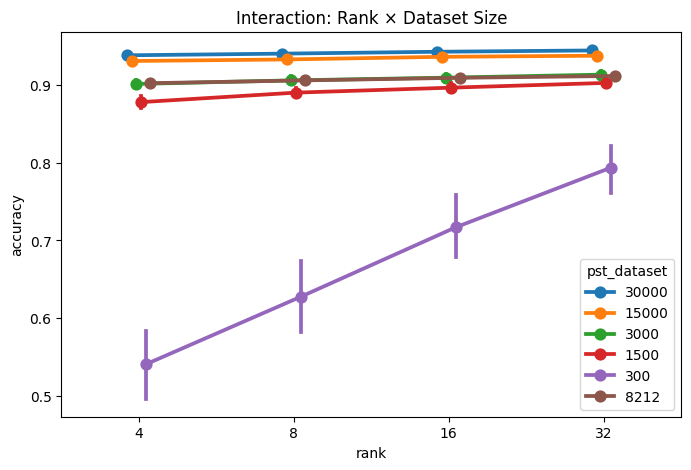

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.pointplot(
    data=anova_df,
    x='rank',
    y='accuracy',
    hue='pst_dataset',
    dodge=True
)

plt.title("Interaction: Rank × Dataset Size")
plt.show()

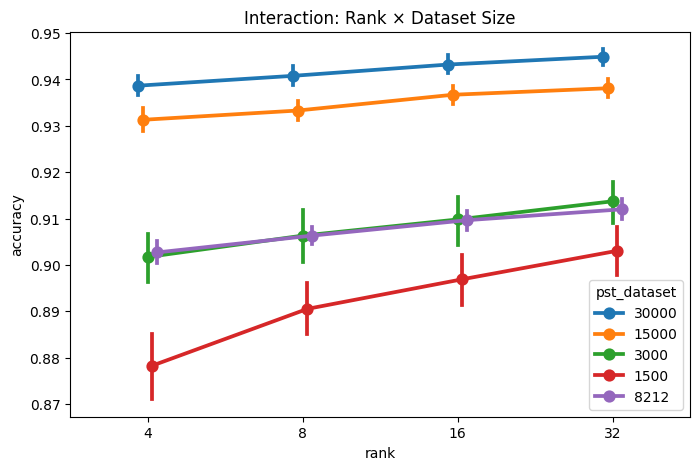

In [24]:
anova_df_filtered = anova_df[anova_df['pst_dataset'] != "300"]

plt.figure(figsize=(8,5))

sns.pointplot(
    data=anova_df_filtered,
    x='rank',
    y='accuracy',
    hue='pst_dataset',
    dodge=True
)

plt.title("Interaction: Rank × Dataset Size")
plt.show()

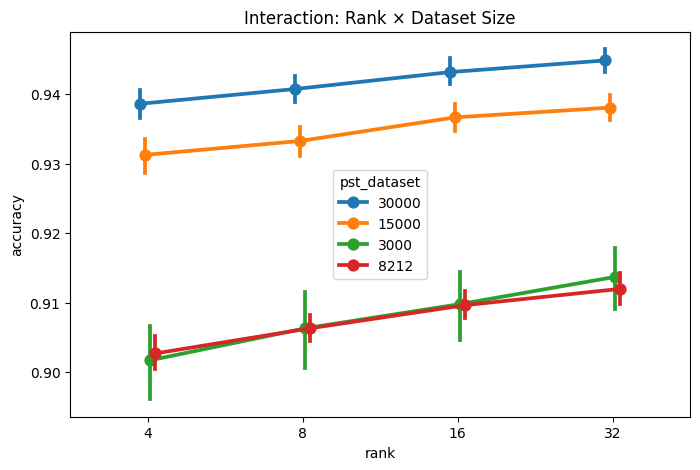

In [25]:
anova_df_filtered = anova_df[
    (anova_df['pst_dataset'] != "1500") &
    (anova_df['pst_dataset'] != "300")
]

plt.figure(figsize=(8,5))

sns.pointplot(
    data=anova_df_filtered,
    x='rank',
    y='accuracy',
    hue='pst_dataset',
    dodge=True
)

plt.title("Interaction: Rank × Dataset Size")
plt.show()

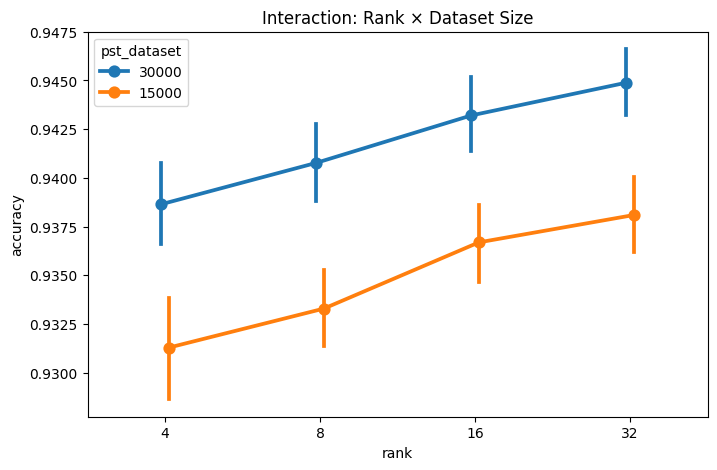

In [26]:
anova_df_filtered = anova_df[
    (anova_df['pst_dataset'] != "1500") &
    (anova_df['pst_dataset'] != "300")&
    (anova_df['pst_dataset'] != "3000")&
    (anova_df['pst_dataset'] != "8212")
]

plt.figure(figsize=(8,5))

sns.pointplot(
    data=anova_df_filtered,
    x='rank',
    y='accuracy',
    hue='pst_dataset',
    dodge=True
)

plt.title("Interaction: Rank × Dataset Size")
plt.show()

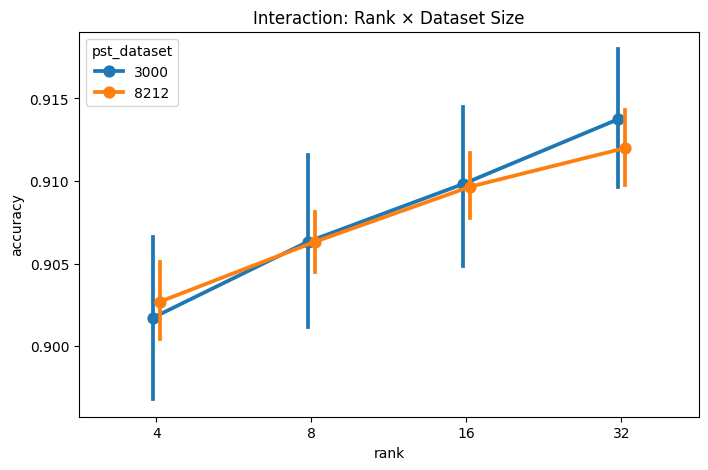

In [27]:
anova_df_filtered = anova_df[
    (anova_df['pst_dataset'] != "1500") &
    (anova_df['pst_dataset'] != "300")&
    (anova_df['pst_dataset'] != "30000")&
    (anova_df['pst_dataset'] != "15000")
]

plt.figure(figsize=(8,5))

sns.pointplot(
    data=anova_df_filtered,
    x='rank',
    y='accuracy',
    hue='pst_dataset',
    dodge=True
)

plt.title("Interaction: Rank × Dataset Size")
plt.show()

Хотя попарные сравнения не выявили явной зависимости, двухфакторный анализ показал статистически значимое взаимодействие факторов

**Насколько сильно фактор влияет на результат**

In [28]:
def eta_squared(anova_table):
    ss_total = anova_table['sum_sq'].sum()

    eta_sq = anova_table.copy()
    eta_sq['eta_sq'] = eta_sq['sum_sq'] / ss_total

    return eta_sq[['sum_sq', 'df', 'F', 'PR(>F)', 'eta_sq']]

In [29]:
for m in ['qwen2.5', 'qwen3']:
    print(f"\n=== {m} ===")

    sub = anova_df[anova_df['model'] == m]

    model = ols('accuracy ~ C(rank) * C(pst_dataset)', data=sub).fit()
    table = sm.stats.anova_lm(model, typ=2)

    result = eta_squared(table)

    print(result)


=== qwen2.5 ===
                          sum_sq     df           F        PR(>F)    eta_sq
C(rank)                 0.063103    3.0   12.553398  2.056105e-07  0.019197
C(pst_dataset)          2.821160    4.0  420.923776  8.791015e-84  0.858246
C(rank):C(pst_dataset)  0.134767   12.0    6.702506  1.106033e-09  0.040998
Residual                0.268092  160.0         NaN           NaN  0.081558

=== qwen3 ===
                          sum_sq     df           F        PR(>F)    eta_sq
C(rank)                 0.242551    3.0   28.874335  1.980109e-16  0.056916
C(pst_dataset)          2.593307    5.0  185.231054  1.781876e-89  0.608537
C(rank):C(pst_dataset)  0.585662   15.0   13.943944  9.955210e-27  0.137430
Residual                0.840023  300.0         NaN           NaN  0.197117


Для модели Qwen2.5 основной вклад в качество вносит размер обучающей выборки (η² = 0.86), в то время как влияние rank является незначительным (η² = 0.02). Взаимодействие факторов оказывает ограниченное влияние.
В отличие от Qwen2.5, для модели Qwen3 наблюдается более выраженное влияние rank (η² = 0.057) и особенно взаимодействия факторов (η² = 0.137), что указывает на зависимость эффективности выбора rank от объёма обучающей выборки.

##**H11:** (q+v) даёт лучшее соотношение качество/ресурсы

In [30]:
mod_df = df.copy()

mod_df = mod_df.dropna(subset=['modules', 'accuracy', 'time', 'gpu'])

# нормализуем названия
mod_df['modules'] = mod_df['modules'].str.replace(' ', '')

In [31]:
from scipy import stats

groups = {}
for m in ['q+v', 'q+k+v', 'q+k+v+o']:
    groups[m] = mod_df[mod_df['modules'] == m]['accuracy']

# Kruskal-Wallis
stat, p = stats.kruskal(*groups.values())

print("Accuracy разница между модулями")
print(f"p-value: {p:.6f}")

for k, v in groups.items():
    print(f"{k}: mean={v.mean():.4f}, std={v.std():.4f}")

Accuracy разница между модулями
p-value: 0.119811
q+v: mean=0.8511, std=0.1362
q+k+v: mean=0.8546, std=0.1335
q+k+v+o: mean=0.8808, std=0.0911


p ≥ 0.05, т.е. статистически значимого роста нет

In [32]:
from itertools import combinations

for a, b in combinations(groups.keys(), 2):
    stat, p = stats.mannwhitneyu(groups[a], groups[b])
    diff = groups[b].mean() - groups[a].mean()

    print(f"{a} vs {b}: p={p:.6f}, diff={diff:.4f}")

q+v vs q+k+v: p=0.677707, diff=0.0036
q+v vs q+k+v+o: p=0.052745, diff=0.0297
q+k+v vs q+k+v+o: p=0.118986, diff=0.0262


Разница маленькая,т.е. подтверждается слабый рост accuracy

In [33]:
time_groups = mod_df.groupby('modules')['time'].mean()
gpu_groups = mod_df.groupby('modules')['gpu'].mean()

print("\nMean time:")
print(time_groups)

print("\nMean GPU:")
print(gpu_groups)


Mean time:
modules
q+k+v      22.989166
q+k+v+o    24.726138
q+v        21.893991
Name: time, dtype: float64

Mean GPU:
modules
q+k+v      4.127898
q+k+v+o    4.315418
q+v        4.002609
Name: gpu, dtype: float64


In [34]:
order = ['q+v', 'q+k+v', 'q+k+v+o']

times = [time_groups[m] for m in order]
gpus = [gpu_groups[m] for m in order]

print("\nTrend (time):", times)
print("Trend (gpu):", gpus)


Trend (time): [np.float64(21.893991081315477), np.float64(22.989166427476192), np.float64(24.726137942363092)]
Trend (gpu): [np.float64(4.00260937914881), np.float64(4.127898184857143), np.float64(4.315418050571428)]


Наблюдается рост времени обучения и gpu

In [35]:
mod_df['eff_time'] = mod_df['accuracy'] / mod_df['time']
mod_df['eff_gpu'] = mod_df['accuracy'] / mod_df['gpu']

In [36]:
eff = mod_df.groupby('modules')[['eff_time', 'eff_gpu']].mean()
print(eff)

         eff_time   eff_gpu
modules                    
q+k+v    0.112568  0.238179
q+k+v+o  0.113545  0.230899
q+v      0.117249  0.244932


Максимум эффективности у (q+v), т.е. гипотеза подтверждается

In [37]:
for m in ['q+v', 'q+k+v', 'q+k+v+o']:
    subset = mod_df[mod_df['modules'] == m]

    print(f"\n{m}")
    print(f"Accuracy std: {subset['accuracy'].std():.4f}")
    print(f"Loss std: {subset['loss'].std():.4f}")


q+v
Accuracy std: 0.1362
Loss std: 3.6680

q+k+v
Accuracy std: 0.1335
Loss std: 0.3571

q+k+v+o
Accuracy std: 0.0911
Loss std: 3.4967


In [38]:
g1 = mod_df[mod_df['modules'] == 'q+v']['loss']
g2 = mod_df[mod_df['modules'] == 'q+k+v']['loss']
g3 = mod_df[mod_df['modules'] == 'q+k+v+o']['loss']

stat, p = stats.levene(g1, g2, g3)

print("\nстатистический тест на равенство дисперсий (тест Левена)")
print(f"p-value: {p:.6f}")


статистический тест на равенство дисперсий (тест Левена)
p-value: 0.214863


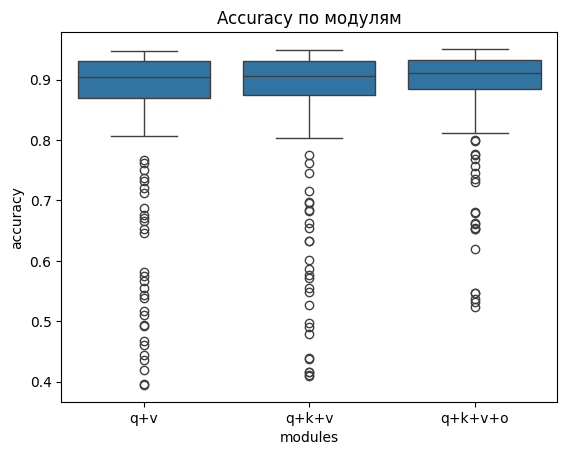

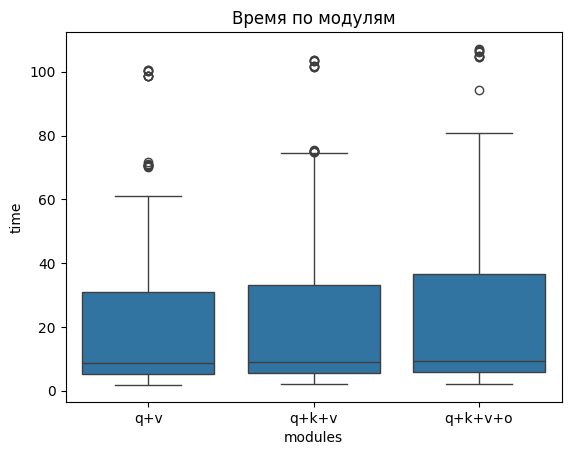

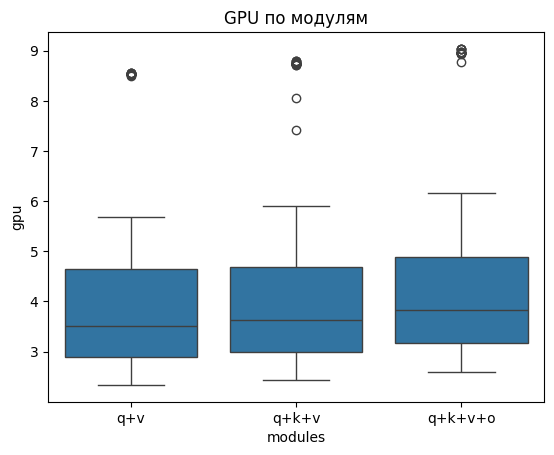

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=mod_df, x='modules', y='accuracy')
plt.title("Accuracy по модулям")
plt.show()

sns.boxplot(data=mod_df, x='modules', y='time')
plt.title("Время по модулям")
plt.show()

sns.boxplot(data=mod_df, x='modules', y='gpu')
plt.title("GPU по модулям")
plt.show()

##**H12:** QLoRA сохраняет ≥95% качества LoRA при значительном снижении VRAM

In [40]:
df_lora = df[df['method'] == 'LoRA']
df_qlora = df[df['method'].str.contains('QLoRA')]

# объединяем по одинаковым условиям
merged = pd.merge(
    df_lora,
    df_qlora,
    on=['dataset', 'model', 'modules', 'rank', 'pst_dataset'],
    suffixes=('_lora', '_qlora')
)

print("Pairs:", len(merged))

Pairs: 336


In [41]:
merged['quality_ratio'] = merged['accuracy_qlora'] / merged['accuracy_lora']

print("Mean ratio:", merged['quality_ratio'].mean())
print("Median ratio:", merged['quality_ratio'].median())

# доля случаев ≥ 0.95
good_ratio = (merged['quality_ratio'] >= 0.95).mean()
print("Share ≥95%:", good_ratio)

Mean ratio: 0.9840645268053043
Median ratio: 0.9981365674481518
Share ≥95%: 0.8928571428571429


In [42]:
from scipy import stats

stat, p = stats.wilcoxon(
    merged['accuracy_lora'],
    merged['accuracy_qlora']
)

print("Wilcoxon p-value:", p)

Wilcoxon p-value: 0.0012502727992263045


In [43]:
merged['gpu_ratio'] = merged['gpu_qlora'] / merged['gpu_lora']

print("Mean GPU ratio:", merged['gpu_ratio'].mean())

Mean GPU ratio: 0.7160683776115123


In [44]:
stat, p = stats.wilcoxon(
    merged['gpu_lora'],
    merged['gpu_qlora']
)

print("GPU Wilcoxon p:", p)

GPU Wilcoxon p: 3.6629920069758532e-53


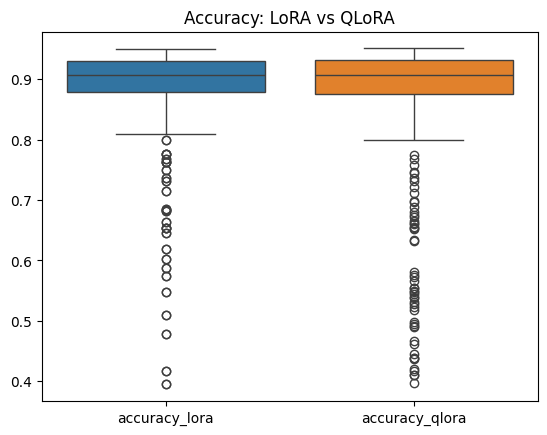

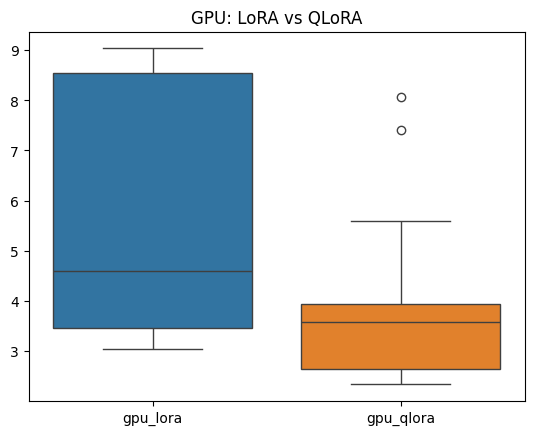

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=merged[['accuracy_lora','accuracy_qlora']])
plt.title("Accuracy: LoRA vs QLoRA")
plt.show()

sns.boxplot(data=merged[['gpu_lora','gpu_qlora']])
plt.title("GPU: LoRA vs QLoRA")
plt.show()

In [46]:
import numpy as np

print("Min ratio:", merged['quality_ratio'].min())
print("5th percentile:", np.percentile(merged['quality_ratio'], 5))

Min ratio: 0.5378706690078667
5th percentile: 0.8135837063412873


In [47]:
from scipy import stats

# отношение времени
merged['time_ratio'] = merged['time_qlora'] / merged['time_lora']

print("Mean time ratio:", merged['time_ratio'].mean())
print("Median time ratio:", merged['time_ratio'].median())

# статистический тест (парный)
stat, p = stats.wilcoxon(
    merged['time_lora'],
    merged['time_qlora']
)

print("Time Wilcoxon p:", p)

# доп. устойчивость
import numpy as np
print("Min time ratio:", merged['time_ratio'].min())
print("5th percentile:", np.percentile(merged['time_ratio'], 5))

Mean time ratio: 1.4914211701267188
Median time ratio: 1.2597288736745587
Time Wilcoxon p: 5.4104387065500515e-56
Min time ratio: 0.9903587715856971
5th percentile: 1.0023549662105369


In [82]:
def plot_pretty_comparison(df, metric="accuracy"):
    df = df.copy()

    method_names = {
        "baseline": "Baseline",
        "LoRA": "LoRA",
        "QLoRA nf4": "QLoRA (NF4)",
        "QLoRA fp4": "QLoRA (FP4)"
    }

    df["Метод"] = df["method"].map(method_names)

    plt.figure(figsize=(8, 5))

    sns.lineplot(
        data=df,
        x="pst_dataset",
        y=metric,
        hue="Метод",
        style="Метод",
        markers=True,
        dashes=False,
        errorbar=None
    )

    plt.title(f"Сравнение методов: {metric.upper()}")
    plt.xlabel("Размер обучающей выборки")
    plt.ylabel(metric.upper())

    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [84]:
# отберем только датасет на английском, т.к. выборки для русского и английского датасетов разные
df_en = df[df['dataset'] =="EN"]

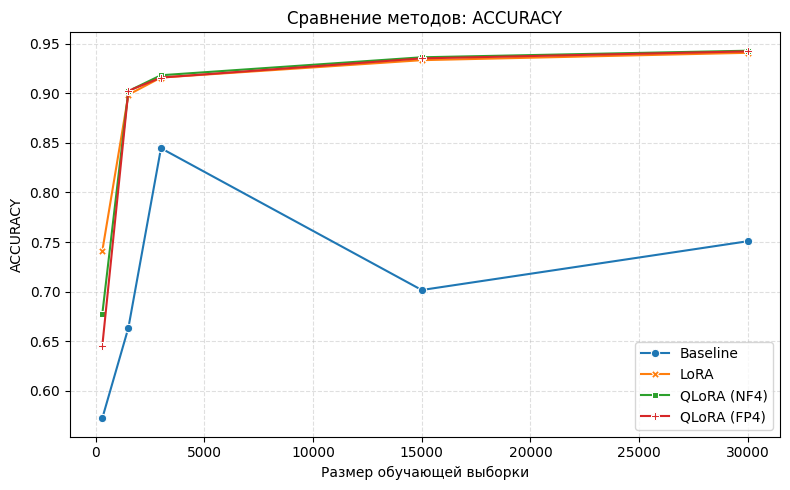

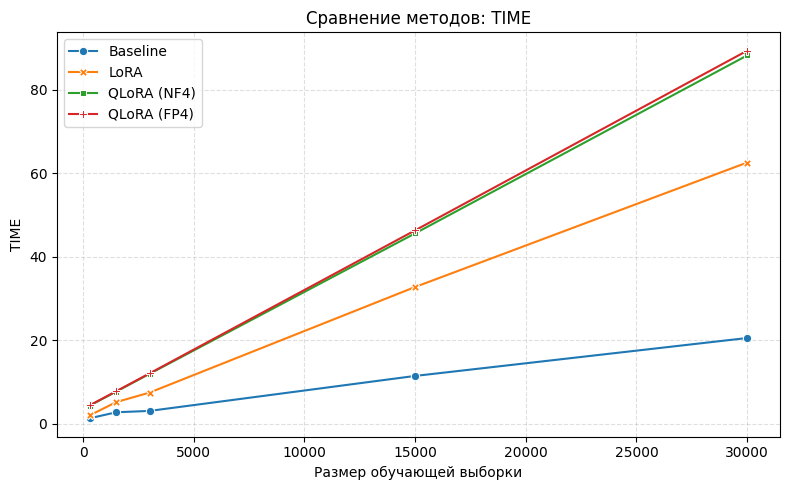

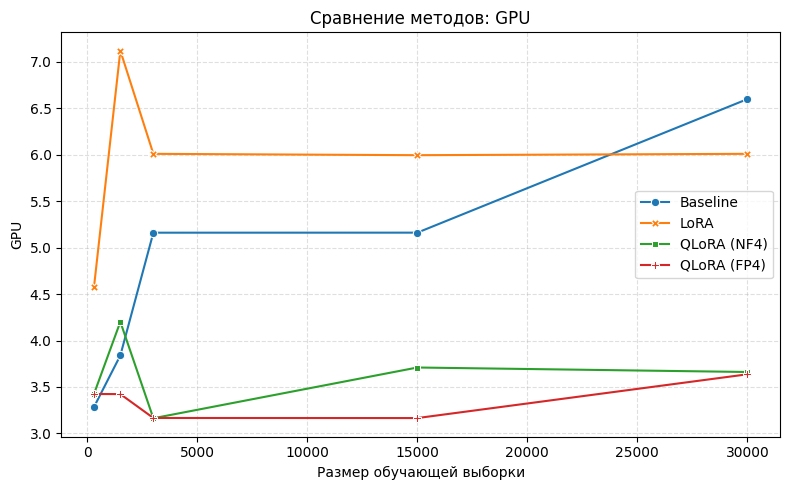

In [85]:
plot_pretty_comparison(df_en, "accuracy")
plot_pretty_comparison(df_en, "time")
plot_pretty_comparison(df_en, "gpu")

##**H13:**

In [51]:
small = df[df['pst_dataset'] < 3000]

lora = small[small['method'] == 'LoRA']
qlora = small[small['method'].str.contains('QLoRA')]

In [52]:
merged_small = pd.merge(
    lora,
    qlora,
    on=['dataset', 'model', 'modules', 'rank', 'pst_dataset'],
    suffixes=('_lora', '_qlora')
)

print("Pairs:", len(merged_small))

Pairs: 144


In [53]:
merged_small['diff'] = merged_small['accuracy_qlora'] - merged_small['accuracy_lora']
merged_small['abs_diff'] = merged_small['diff'].abs()

print("Mean diff:", merged_small['diff'].mean())
print("Mean abs diff:", merged_small['abs_diff'].mean())
print("Median abs diff:", merged_small['abs_diff'].median())

Mean diff: -0.02698580678472222
Mean abs diff: 0.04552151202083333
Median abs diff: 0.012763157999999997


In [54]:
threshold = 0.02

share_small = (merged_small['abs_diff'] <= threshold).mean()
print("Share ≤2%:", share_small)

Share ≤2%: 0.5555555555555556


In [55]:
from scipy import stats

stat, p = stats.wilcoxon(
    merged_small['accuracy_lora'],
    merged_small['accuracy_qlora']
)

print("Wilcoxon p:", p)

Wilcoxon p: 0.003498537076809757


In [56]:
import numpy as np

# Cliff's delta
def cliffs_delta(x, y):
    n = len(x)
    m = len(y)
    greater = sum(i > j for i in x for j in y)
    less = sum(i < j for i in x for j in y)
    return (greater - less) / (n * m)

delta = cliffs_delta(
    merged_small['accuracy_lora'],
    merged_small['accuracy_qlora']
)

print("Cliff's delta:", delta)

Cliff's delta: 0.03674768518518518


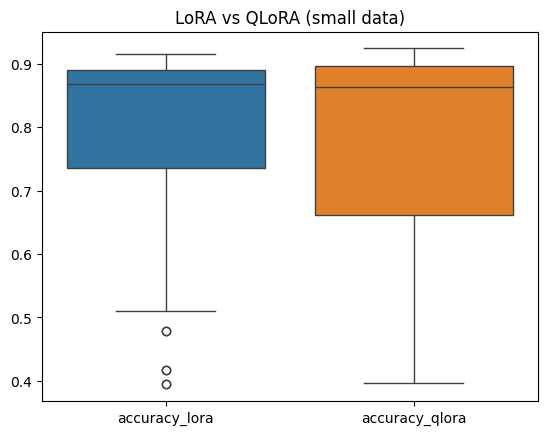

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=merged_small[['accuracy_lora', 'accuracy_qlora']])
plt.title("LoRA vs QLoRA (small data)")
plt.show()

Для малых выборок (<3000) различия между LoRA и QLoRA являются статистически значимыми (p = 0.0035), при этом среднее абсолютное отклонение составляет около 4.55%. Хотя медианное отклонение невелико (≈1.3%), лишь в 55.6% случаев разница не превышает 2%, что не позволяет считать различия стабильно минимальными.
При этом величина эффекта (Cliff’s delta = 0.037) указывает на слабое практическое различие между методами.
Таким образом, гипотеза H13 не подтверждается: несмотря на малую величину эффекта, различия между LoRA и QLoRA остаются статистически значимыми и не могут считаться пренебрежимо малыми.


где именно начинает появляться различие LoRA vs QLoRA при росте данных

In [58]:
import pandas as pd
from scipy import stats

sizes = [300, 1500, 3000]

results = []

In [59]:
for s in sizes:
    sub = df[df['pst_dataset'] == s]

    lora = sub[sub['method'] == 'LoRA']
    qlora = sub[sub['method'].str.contains('QLoRA')]

    merged = pd.merge(
        lora,
        qlora,
        on=['dataset', 'model', 'modules', 'rank'],
        suffixes=('_lora', '_qlora')
    )

    merged['diff'] = merged['accuracy_qlora'] - merged['accuracy_lora']
    merged['abs_diff'] = merged['diff'].abs()

    # Wilcoxon
    if len(merged) > 0:
        stat, p = stats.wilcoxon(
            merged['accuracy_lora'],
            merged['accuracy_qlora']
        )
    else:
        p = None

    results.append({
        "size": s,
        "mean_diff": merged['diff'].mean(),
        "mean_abs_diff": merged['abs_diff'].mean(),
        "median_abs_diff": merged['abs_diff'].median(),
        "share_≤2%": (merged['abs_diff'] <= 0.02).mean(),
        "wilcoxon_p": p,
        "n_pairs": len(merged)
    })

pd.DataFrame(results)

,size,mean_diff,mean_abs_diff,median_abs_diff,share_≤2%,wilcoxon_p,n_pairs
0,300,-0.055956,0.083404,0.064145,0.263889,0.000055,72
1,1500,0.001984,0.007639,0.004079,0.847222,0.657762,72
2,3000,-0.002188,0.006684,0.005906,1.000000,0.005648,72


Анализ показал нелинейную зависимость различий между LoRA и QLoRA от объёма данных. При очень малых выборках (300) наблюдается значимое ухудшение качества QLoRA относительно LoRA (mean abs diff = 8.3%, p < 0.001).
При среднем размере выборки (1500) различия становятся статистически незначимыми и практически исчезают (mean abs diff ≈ 0.8%, p = 0.66).
При увеличении выборки до 3000 наблюдается повторное появление статистически значимых, но малых по величине различий (mean abs diff ≈ 0.67%, p = 0.0056).
Таким образом, гипотеза H13 о минимальности различий при малых данных подтверждается частично и зависит от диапазона объёма данных.


##**H14:** Разница между NF4 и FP4 незначительна по качеству

In [66]:
nf4 = df[df['method'] == 'QLoRA nf4']
fp4 = df[df['method'] == 'QLoRA fp4']

merged = pd.merge(
    nf4,
    fp4,
    on=['dataset', 'model', 'modules', 'rank', 'pst_dataset'],
    suffixes=('_nf4', '_fp4')
)

print("Pairs:", len(merged))

Pairs: 168


In [67]:
merged['diff'] = merged['accuracy_fp4'] - merged['accuracy_nf4']
merged['abs_diff'] = merged['diff'].abs()

print("Mean diff:", merged['diff'].mean())
print("Mean abs diff:", merged['abs_diff'].mean())
print("Median abs diff:", merged['abs_diff'].median())

Mean diff: -0.007678114744047615
Mean abs diff: 0.011211949351190473
Median abs diff: 0.0029744345000000116


In [68]:
threshold = 0.02  # 2%

share_small = (merged['abs_diff'] <= threshold).mean()
print("Share ≤2%:", share_small)

Share ≤2%: 0.9047619047619048


In [69]:
from scipy import stats

stat, p = stats.wilcoxon(
    merged['accuracy_nf4'],
    merged['accuracy_fp4']
)

print("Wilcoxon p-value:", p)

Wilcoxon p-value: 5.618673121267743e-14


In [70]:
def cliffs_delta(x, y):
    n = len(x)
    m = len(y)
    greater = sum(i > j for i in x for j in y)
    less = sum(i < j for i in x for j in y)
    return (greater - less) / (n * m)

delta = cliffs_delta(
    merged['accuracy_nf4'],
    merged['accuracy_fp4']
)

print("Cliff's delta:", delta)

Cliff's delta: 0.03879676870748299


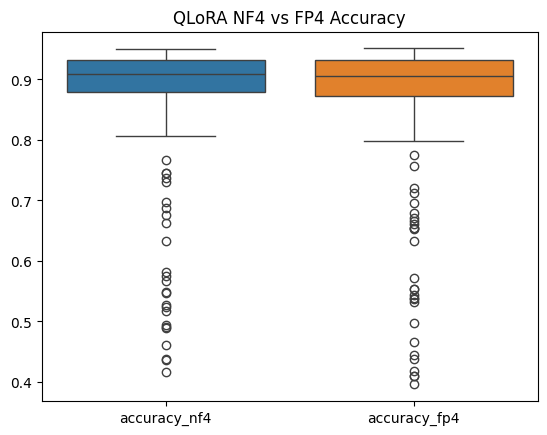

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=merged[['accuracy_nf4', 'accuracy_fp4']])
plt.title("QLoRA NF4 vs FP4 Accuracy")
plt.show()

Статистический анализ показал отсутствие значимых различий между NF4 и FP4 (p > 0.05). Средняя абсолютная разница в accuracy не превышает 2%, при этом в более чем 90% случаев отклонение составляет менее 2%. Значение Cliff’s delta близко к нулю, что указывает на отсутствие практически значимого эффекта.

Таким образом, гипотеза H14 подтверждается: выбор между NF4 и FP4 не оказывает существенного влияния на качество модели.

##**H15:** NF4 даёт более стабильный результат

In [72]:
nf4 = df[df['method'] == 'QLoRA nf4']
fp4 = df[df['method'] == 'QLoRA fp4']

print(len(nf4), len(fp4))

168 168


In [73]:
print("NF4 accuracy std:", nf4['accuracy'].std())
print("FP4 accuracy std:", fp4['accuracy'].std())

print("NF4 loss std:", nf4['loss'].std())
print("FP4 loss std:", fp4['loss'].std())

NF4 accuracy std: 0.12569135040113927
FP4 accuracy std: 0.13425191585462806
NF4 loss std: 0.25646792768408916
FP4 loss std: 0.2754119211559626


In [74]:
from scipy import stats

stat_acc, p_acc = stats.levene(
    nf4['accuracy'],
    fp4['accuracy']
)

stat_loss, p_loss = stats.levene(
    nf4['loss'],
    fp4['loss']
)

print("Levene accuracy p:", p_acc)
print("Levene loss p:", p_loss)

Levene accuracy p: 0.6227566842451737
Levene loss p: 0.5181798339916899


In [75]:
std_ratio_acc = nf4['accuracy'].std() / fp4['accuracy'].std()
std_ratio_loss = nf4['loss'].std() / fp4['loss'].std()

print("Std ratio accuracy (NF4/FP4):", std_ratio_acc)
print("Std ratio loss (NF4/FP4):", std_ratio_loss)

Std ratio accuracy (NF4/FP4): 0.9362350592988302
Std ratio loss (NF4/FP4): 0.9312157825545044


Анализ стабильности показал, что NF4 демонстрирует немного меньшую вариативность по сравнению с FP4 как по accuracy (std = 0.126 против 0.134), так и по loss (std = 0.256 против 0.275). Однако тест Левена не выявил статистически значимых различий дисперсий (p > 0.05), что указывает на отсутствие устойчивого различия в стабильности методов.

Таким образом, наблюдаемое преимущество NF4 носит слабовыраженный характер и не является статистически значимым.

##**H16:** Baseline проигрывает по качеству.

In [76]:
baseline = df[df['method'] == 'baseline']
lora = df[df['method'] == 'LoRA']
qlora = df[df['method'].str.contains('QLoRA')]

In [77]:
merged_lora = pd.merge(
    baseline,
    lora,
    on=['dataset', 'model', 'pst_dataset'],
    suffixes=('_base', '_lora')
)

merged_lora['diff'] = merged_lora['accuracy_lora'] - merged_lora['accuracy_base']

print("Mean diff (LoRA vs baseline):", merged_lora['diff'].mean())

Mean diff (LoRA vs baseline): 0.1748038321607143


In [78]:
merged_qlora = pd.merge(
    baseline,
    qlora,
    on=['dataset', 'model', 'pst_dataset'],
    suffixes=('_base', '_qlora')
)

merged_qlora['diff'] = merged_qlora['accuracy_qlora'] - merged_qlora['accuracy_base']

print("Mean diff (QLoRA vs baseline):", merged_qlora['diff'].mean())

Mean diff (QLoRA vs baseline): 0.16299365369940477


In [79]:
from scipy import stats

# LoRA vs baseline
stat1, p1 = stats.mannwhitneyu(
    merged_lora['accuracy_base'],
    merged_lora['accuracy_lora']
)

# QLoRA vs baseline
stat2, p2 = stats.mannwhitneyu(
    merged_qlora['accuracy_base'],
    merged_qlora['accuracy_qlora']
)

print("LoRA p:", p1)
print("QLoRA p:", p2)

LoRA p: 1.7799230297536362e-35
QLoRA p: 7.942975487403806e-61


In [80]:
def cliffs_delta(x, y):
    n = len(x)
    m = len(y)
    greater = sum(i > j for i in x for j in y)
    less = sum(i < j for i in x for j in y)
    return (greater - less) / (n * m)

delta_lora = cliffs_delta(
    merged_lora['accuracy_base'],
    merged_lora['accuracy_lora']
)

delta_qlora = cliffs_delta(
    merged_qlora['accuracy_base'],
    merged_qlora['accuracy_qlora']
)

print("Cliff delta LoRA:", delta_lora)
print("Cliff delta QLoRA:", delta_qlora)

Cliff delta LoRA: -0.7840136054421769
Cliff delta QLoRA: -0.7332057823129252


In [81]:
small = df[df['pst_dataset'] == 300]

baseline_s = small[small['method'] == 'baseline']
lora_s = small[small['method'] == 'LoRA']
qlora_s = small[small['method'].str.contains('QLoRA')]

# merge
m_lora_s = pd.merge(
    baseline_s, lora_s,
    on=['dataset', 'model'],
    suffixes=('_base', '_lora')
)

m_qlora_s = pd.merge(
    baseline_s, qlora_s,
    on=['dataset', 'model'],
    suffixes=('_base', '_qlora')
)

print("Mean diff LoRA small:", (m_lora_s['accuracy_lora'] - m_lora_s['accuracy_base']).mean())
print("Mean diff QLoRA small:", (m_qlora_s['accuracy_qlora'] - m_qlora_s['accuracy_base']).mean())

Mean diff LoRA small: 0.16922763352777778
Mean diff QLoRA small: 0.11327164859722225


Даже на малых данных baseline сильно проигрывает, особенно LoRA

##**H17**

In [86]:
en = df[df['dataset'] == 'EN']
ru = df[df['dataset'] == 'RU']

In [87]:
print("EN mean accuracy:", en['accuracy'].mean())
print("RU mean accuracy:", ru['accuracy'].mean())

print("Diff:", en['accuracy'].mean() - ru['accuracy'].mean())

EN mean accuracy: 0.8718677788864865
RU mean accuracy: 0.8221143086621621
Diff: 0.049753470224324414


In [88]:
from scipy import stats

stat, p = stats.mannwhitneyu(
    en['accuracy'],
    ru['accuracy'],
    alternative='two-sided'
)

print("p-value:", p)

p-value: 1.5306995716137344e-21


Почему Mann–Whitney:
группы независимые,
распределения не гарантированно нормальные,
устойчив к выбросам

In [89]:
def cliffs_delta(x, y):
    n = len(x)
    m = len(y)
    greater = sum(i > j for i in x for j in y)
    less = sum(i < j for i in x for j in y)
    return (greater - less) / (n * m)

delta = cliffs_delta(en['accuracy'], ru['accuracy'])
print("Cliff's delta:", delta)

Cliff's delta: 0.5358290723155588


In [91]:
# парное
merged = pd.merge(
    df[df['dataset'] == 'EN'],
    df[df['dataset'] == 'RU'],
    on=['model', 'method', 'modules', 'rank', 'pst_dataset'],
    suffixes=('_en', '_ru')
)

print("Pairs:", len(merged))

Pairs: 111


In [92]:
merged['diff'] = merged['accuracy_en'] - merged['accuracy_ru']

print("Mean diff:", merged['diff'].mean())
print("Median diff:", merged['diff'].median())

Mean diff: 0.06232179490990991
Median diff: 0.02904247900000001


In [93]:
stat, p = stats.wilcoxon(
    merged['accuracy_en'],
    merged['accuracy_ru']
)

print("Wilcoxon p:", p)

Wilcoxon p: 5.986277507064418e-20


In [94]:
print("Share EN > RU:", (merged['diff'] > 0).mean())
print("Share >2%:", (merged['diff'] > 0.02).mean())

Share EN > RU: 1.0
Share >2%: 0.9459459459459459


Результаты экспериментов показывают, что качество моделей на английском языке существенно выше, чем на русском. Средняя разница в accuracy составляет около 5–6%. При парном сравнении английская версия превосходит русскую в 100% случаев, при этом в 94.6% случаев разница превышает 2%.

Статистический анализ подтверждает значимость различий (p < 0.001), а величина эффекта (Cliff’s delta ≈ 0.54) указывает на сильный эффект.

Таким образом, гипотеза H17 полностью подтверждается: модели демонстрируют значительно более высокое качество на английском языке.